# Hessian & Taylor Expansion

对梯度再求一次导，得到 **Hessian 矩阵**——多元函数的"曲率"。它决定：函数是否凸（极小值判据）、梯度下降能走多快（条件数）、以及牛顿法为什么能加速。


## 0. 环境配置与导入


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import matplotlib

# 中文字体：避免图上中文显示为方块（macOS 用苹方，Windows 用微软雅黑）
matplotlib.rcParams["font.sans-serif"] = ["PingFang SC", "Hiragino Sans GB", "Arial Unicode MS", "Microsoft YaHei", "sans-serif"]
matplotlib.rcParams["axes.unicode_minus"] = False   # 修复负号显示为方块

print("PyTorch version:", torch.__version__)
torch.manual_seed(42)


PyTorch version: 2.13.0


## 1. 从二阶导数到 Hessian 矩阵


### 1.1 定义与对称性

$$H_{ij} = \frac{\partial^2 f}{\partial x_i \partial x_j}$$

即梯度的 Jacobian。**克莱罗定理**：只要二阶偏导连续，混合偏导与求导顺序无关，$H_{ij} = H_{ji}$，Hessian 是对称矩阵——这使它可以做特征分解，直接衔接 linear-algebra 的谱理论。


In [2]:
def hessian_numeric(f, x, h=1e-4):
    """f: R^n → R，返回 n×n Hessian（中心差分）"""
    x = np.asarray(x, dtype=float)
    n = len(x)
    H = np.zeros((n, n))
    for i in range(n):
        ei = np.eye(n)[i]
        if True:
            H[i, i] = (f(x + h*ei) - 2*f(x) + f(x - h*ei)) / h**2
        for j in range(i+1, n):
            ej = np.eye(n)[j]
            H[i, j] = (f(x + h*ei + h*ej) - f(x + h*ei - h*ej)
                       - f(x - h*ei + h*ej) + f(x - h*ei - h*ej)) / (4*h**2)
            H[j, i] = H[i, j]
    return H

f = lambda x: x[0]**3 * x[1] + np.sin(x[0]*x[1]) + x[1]**2
x0 = np.array([0.8, -0.3])
H = hessian_numeric(f, x0)

# 解析 Hessian（手推）
c0, c1 = x0
H_ana = np.array([
    [6*c0*c1 - c1**2*np.sin(c0*c1),
     3*c0**2 + np.cos(c0*c1) - c0*c1*np.sin(c0*c1)],
    [3*c0**2 + np.cos(c0*c1) - c0*c1*np.sin(c0*c1),
     -c0**2*np.sin(c0*c1) + 2],
])
print("数值 Hessian:\n", np.round(H, 6))
print("最大误差:", np.abs(H - H_ana).max())
print("对称性 ‖H − Hᵀ‖:", np.abs(H - H.T).max(), "（克莱罗定理成立）")


数值 Hessian:
 [[-1.418607  2.834289]
 [ 2.834289  2.15213 ]]
最大误差: 1.0210849943348421e-08
对称性 ‖H − Hᵀ‖: 0.0 （克莱罗定理成立）


## 2. 多元二阶泰勒展开


$$f(x + \Delta x) \approx f(x) + \underbrace{\nabla f^\mathsf{T}\Delta x}_{\text{一阶}} + \tfrac12\underbrace{\Delta x^\mathsf{T} H \Delta x}_{\text{二阶}}$$

- 一阶项：沿梯度方向的线性变化
- 二阶项：曲率修正，由 Hessian 完全决定

代码验证误差阶数：一阶近似误差 $O(|\Delta x|^2)$，二阶近似误差 $O(|\Delta x|^3)$——log-log 图上斜率分别是 2 和 3。


Text(0.5, 1.0, '误差阶数：二阶泰勒比一阶精确一个数量级')

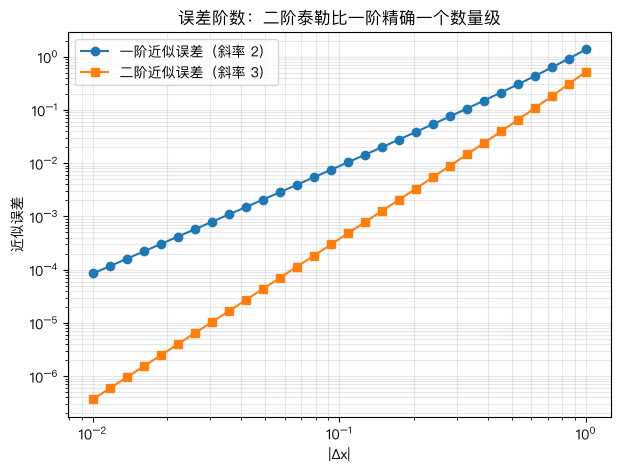

In [3]:
f = lambda x: np.exp(x[0] + x[1])          # 非二次函数，二阶近似才有误差
x0 = np.array([0.0, 0.0])
g = np.array([1.0, 1.0])                       # ∇f(0)
H = np.array([[1., 1.], [1., 1.]])             # Hessian f(0)

ds = 10.0 ** np.linspace(-2, 0, 30)
err1, err2 = [], []
for d in ds:
    dx = np.array([d, 0.3*d])
    exact = f(x0 + dx)
    lin  = f(x0) + g @ dx
    quad = lin + 0.5 * dx @ H @ dx
    err1.append(abs(exact - lin))
    err2.append(abs(exact - quad))

plt.figure(figsize=(7, 5))
plt.loglog(ds, err1, 'o-', label='一阶近似误差（斜率 2）')
plt.loglog(ds, err2, 's-', label='二阶近似误差（斜率 3）')
plt.xlabel('|Δx|'); plt.ylabel('近似误差')
plt.legend(); plt.grid(alpha=0.3, which='both')
plt.title('误差阶数：二阶泰勒比一阶精确一个数量级')


## 3. Hessian 与凸性：极小值判据


在驻点（$\nabla f = 0$）处，二阶项 $\tfrac12\Delta x^\mathsf{T}H\Delta x$ 决定局部形状：

| Hessian | 类型 | 局部形状 |
|---------|------|---------|
| 正定（全部特征值 > 0） | 严格凸 | 唯一极小值（碗底） |
| 半正定 | 凸 | 极小但不唯一 |
| 负定 | 严格凹 | 极大值 |
| 不定（特征值有正有负） | 鞍点 | 既非极大也非极小 |

这与 linear-algebra 07 的正定矩阵判定完全一致：**二次型的符号就是 Hessian 的符号**。代码可视化三种典型：


正定: 特征值 = [2. 2.] → 全部>0，极小
不定: 特征值 = [-2.  2.] → 有正有负，鞍点
负定: 特征值 = [-2. -2.] → 全部<0，极大


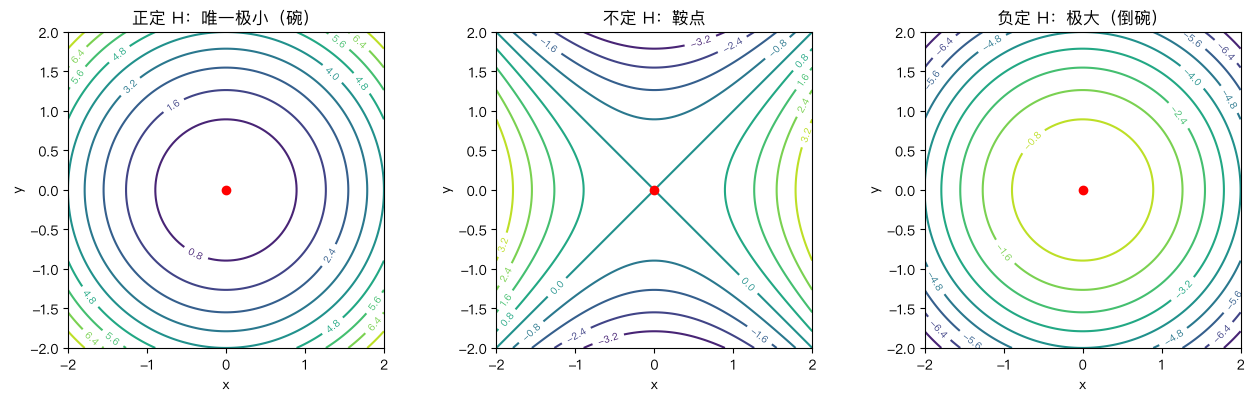

In [4]:
def contour_of(f, title, ax):
    xs = np.linspace(-2, 2, 100); ys = np.linspace(-2, 2, 100)
    X, Y = np.meshgrid(xs, ys)
    cs = ax.contour(X, Y, f(X, Y), levels=12, cmap='viridis')
    ax.clabel(cs, inline=True, fontsize=7)
    ax.scatter(0, 0, color='red', zorder=5)
    ax.set_title(title); ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.set_aspect('equal')

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
contour_of(lambda X, Y: X**2 + Y**2, '正定 H：唯一极小（碗）', axes[0])
contour_of(lambda X, Y: X**2 - Y**2, '不定 H：鞍点', axes[1])
contour_of(lambda X, Y: -X**2 - Y**2, '负定 H：极大（倒碗）', axes[2])

for name, H in [('正定', np.diag([2., 2.])), ('不定', np.diag([2., -2.])), ('负定', np.diag([-2., -2.]))]:
    ev = np.linalg.eigvalsh(H)
    print(f"{name}: 特征值 = {np.round(ev, 2)} → {'全部>0，极小' if (ev>0).all() else ('全部<0，极大' if (ev<0).all() else '有正有负，鞍点')}")
plt.tight_layout()


## 4. 牛顿法：用二阶信息加速


### 4.1 推导

对二阶泰勒近似求驻点：$\nabla f(x) + H\Delta x = 0$，解得：

$$\Delta x^* = -H^{-1}\nabla f(x)$$

牛顿法每一步都走到**二次近似的极小点**，而不是像梯度下降那样沿切线走一小步。对二次函数，一步到位。


Text(0.5, 1.0, '病态二次型：GD 之字形震荡 vs 牛顿法沿曲率方向一步到位')

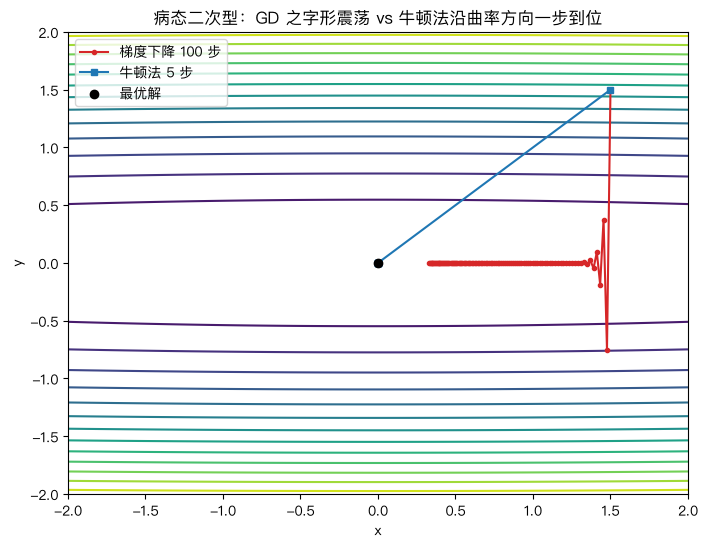

In [5]:
# 病态二次型：f = ½(x² + 100y²)，Hessian = diag(1, 100)
H = np.array([[1., 0.], [0., 100.]])
g = lambda x: H @ x

def gd(x0, lr, steps):
    xs = [x0]; x = x0.copy()
    for _ in range(steps):
        x = x - lr * g(x)
        xs.append(x.copy())
    return np.array(xs)

def newton(x0, steps):
    xs = [x0]; x = x0.copy()
    Hinv = np.linalg.inv(H)
    for _ in range(steps):
        x = x - Hinv @ g(x)          # Δx = -H⁻¹∇f
        xs.append(x.copy())
    return np.array(xs)

x0 = np.array([1.5, 1.5])
gd_traj = gd(x0, 0.015, 100)         # 学习率需 < 2/λmax = 0.02
nw_traj = newton(x0, 5)

xs = np.linspace(-2, 2, 100); ys = np.linspace(-2, 2, 100)
X, Y = np.meshgrid(xs, ys)
Z = 0.5 * (X**2 + 100*Y**2)

plt.figure(figsize=(8, 6))
plt.contour(X, Y, Z, levels=15, cmap='viridis')
plt.plot(gd_traj[:, 0], gd_traj[:, 1], 'o-', color='tab:red', markersize=3, label='梯度下降 100 步')
plt.plot(nw_traj[:, 0], nw_traj[:, 1], 's-', color='tab:blue', markersize=5, label='牛顿法 5 步')
plt.scatter([0], [0], color='black', zorder=5, label='最优解')
plt.legend(); plt.xlabel('x'); plt.ylabel('y')
plt.title('病态二次型：GD 之字形震荡 vs 牛顿法沿曲率方向一步到位')


## 5. 曲率、条件数与梯度下降


### 5.1 为什么病态 Hessian 让 GD 变慢

对 $f = \tfrac12 x^\mathsf{T}H x$，沿特征向量方向 $e_i$ 的收敛速率为 $|1 - \alpha\lambda_i|$。要所有方向都收敛必须 $\alpha < 2/\lambda_{\max}$，于是：

- 最大特征值方向：走一步可能过头 → 振荡
- 最小特征值方向：按同一学习率走，进展极慢 → 之字形

**条件数 $\kappa = \lambda_{\max}/\lambda_{\min}$ 越大，GD 越慢**——这是深度学习中"预处理/自适应方法"（Adam 等，06 课）存在的根本原因。


In [6]:
H = np.array([[1., 0.], [0., 100.]])
evals = np.linalg.eigvalsh(H)
print(f"H 特征值 = {evals}")
print(f"2/λ_max = {2/evals.max():.4f} → 学习率必须小于它，否则 y 方向发散")
print(f"条件数 κ = {evals.max()/evals.min():.1f} → 越大，x 方向收敛越慢")


H 特征值 = [  1. 100.]
2/λ_max = 0.0200 → 学习率必须小于它，否则 y 方向发散
条件数 κ = 100.0 → 越大，x 方向收敛越慢


## 6. 深度学习中的 Hessian


### 6.1 为什么不显式算 Hessian

$n$ 个参数 → Hessian 有 $n^2$ 个元素、求逆 $O(n^3)$。百万参数的模型根本无法存储。深度学习只使用**Hessian-向量积（HVP）**：用梯度的有限差分，一次只要 $O(n)$：

$$H\,v \approx \frac{\nabla f(x + \varepsilon v) - \nabla f(x - \varepsilon v)}{2\varepsilon}$$

代价 = 两次反向传播，不需要碰 $n^2$ 矩阵。Adam 等优化器正是在用一阶信息**近似**曲率。


In [7]:
def hvp_numeric(grad_f, x, v, eps=1e-6):
    return (grad_f(x + eps*v) - grad_f(x - eps*v)) / (2 * eps)

f = lambda x: np.exp(x[0]) * x[1]**2
grad_f = lambda x: np.array([np.exp(x[0])*x[1]**2, 2*np.exp(x[0])*x[1]])
x0 = np.array([0.3, 0.8])
v = np.array([0.7, -0.4])

Hv = hvp_numeric(grad_f, x0, v)
H  = hessian_numeric(f, x0)
print("H·v（有限差分）:", Hv)
print("H·v（显式 H）  :", H @ v)
print("最大误差:", np.abs(Hv - H @ v).max())
print("→ 只花两次反向传播的代价，就拿到曲率信息，无需 n² 存储")


H·v（有限差分）: [-0.25917289  0.43195482]
H·v（显式 H）  : [-0.2591729   0.43195482]
最大误差: 1.2045919817182948e-08
→ 只花两次反向传播的代价，就拿到曲率信息，无需 n² 存储


## 课后练习


1. **手推 Hessian**：$f(x,y) = e^{xy}$，手写 $2\times2$ Hessian，验证对称性并用数值 Hessian 核对。
2. **凸性证明**：用二阶泰勒说明为什么 $H$ 正定 → 在驻点处 $f$ 严格凸（提示：二阶项 $\tfrac12\Delta x^\mathsf{T}H\Delta x > 0$ 对所有 $\Delta x \ne 0$ 成立）。
3. **最优学习率**：对 $f = \tfrac12(x^2 + 100y^2)$，手算最大稳定学习率并验证 GD 在此学习率下收敛、超一点就发散。
4. **牛顿法非二次**：对 $f = x^4 + y^4$，用解析梯度/Hessian 跑 3 步牛顿法，观察与二次情形的差异。
5. **HVP 思考**：为什么深网从不存完整 Hessian？HVP 为什么可行？（提示：两次 backward 的成本 vs $n^2$ 存储）
